# Sim-to-Real Betting on the E-Process
*Bringing "simulators" to anytime-valid confidence sequences*

In [10]:
# Setup: install deps and clone the RSS paper's code next to this notebook.
import os, sys, subprocess

def sh(*cmd):
    subprocess.run(list(cmd), check=True)

sh(sys.executable, "-m", "pip", "install", "-q", "numpy", "scipy", "matplotlib")
if not os.path.isdir("Bet4Sim2Real"):
    sh("git", "clone", "--depth", "1", "https://github.com/ISUSAIL/Bet4Sim2Real.git")
sys.path.insert(0, os.path.abspath("Bet4Sim2Real/synthetic_examples"))

Cloning into 'Bet4Sim2Real'...


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import demo
from distributions import (BetaSkewed, TruncatedNormal, BimodalMixture,
                           GaussianMixture, UniformSpike)

REAL_SETS = {
    "Real_6":  [d for _, d in demo.TEST_DISTRIBUTIONS_Real_6],
    "Real_20": [d for _, d in demo.TEST_DISTRIBUTIONS_Real_20],
    "Real_40": [d for _, d in demo.TEST_DISTRIBUTIONS_Real_40],
}
BANKS = {
    "Sim_35":  demo.make_optimized_sparse_bank,
    "Sim_94":  demo.make_multi_resolution_bank,
    "Sim_172": demo.make_ultra_dense_local_bank,
}

In [12]:
# Real_8 and Sim_30: a 30-expert bank matching Real_8's first two moments with different shapes.
def make_real_8():
    return [
        BimodalMixture(0.30), BimodalMixture(0.50),
        GaussianMixture([0.2, 0.8], [0.10, 0.10], [0.5, 0.5]),
        GaussianMixture([0.1, 0.9], [0.08, 0.08], [0.5, 0.5]),
        TruncatedNormal(0.50, 0.25), TruncatedNormal(0.35, 0.24),
        UniformSpike(0.50, 0.30),
        GaussianMixture([0.3, 0.7], [0.12, 0.12], [0.4, 0.6]),
    ]

def beta_matching(mu, var):
    s = mu * (1 - mu) / var - 1.0
    return BetaSkewed(max(mu * s, 0.04), max((1 - mu) * s, 0.04))

def make_sim_30():
    moments = [(float(d.true_mean()), float(d.true_variance())) for d in make_real_8()]
    experts = [beta_matching(m, v) for m, v in moments]
    jitter = [(0.03, 1.0), (-0.03, 1.0), (0.0, 0.85), (0.0, 1.15), (0.05, 0.9), (-0.05, 1.1)]
    i = 0
    while len(experts) < 30:
        m, v = moments[i % len(moments)]
        dm, dv = jitter[(i // len(moments)) % len(jitter)]
        m2 = min(max(m + dm, 0.05), 0.95)
        v2 = min(max(v * dv, 0.01), m2 * (1 - m2) * 0.95)
        experts.append(beta_matching(m2, v2))
        i += 1
    return experts

REAL_SETS["Real_8"] = make_real_8()
BANKS["Sim_30"] = make_sim_30

In [ ]:
ALPHA = 0.05
ETA   = 5.0
DELTA = 0.05
GRID  = np.round(np.arange(0.02, 1.00, 0.02), 2)
KAPPA = {"data-driven": 0.5, "ideal": 1.0, "proposed": 1.0}


def truncate(lam, mu0):
    """ALGORITHM Line 6: Clip the stake so every betting factor stays positive for any y in [0, 1]."""
    return np.clip(lam, -(1 - DELTA) / np.maximum(1 - mu0, 1e-6),
                         (1 - DELTA) / np.maximum(mu0, 1e-6))


def gauss_loglik(y, mu, var):
    """ALGORITHM Line 9: Update the log-score of every banks."""
    return -0.5 * (np.log(2 * np.pi * var) + (y - mu) ** 2 / var)


def bank_mixture(experts, ys, eta=ETA):
    """ALGORITHM Line 3: Compute trust-weighted mixture (mean, variance) of the bank."""
    mu  = np.array([e.true_mean() for e in experts], float)
    var = np.maximum(np.array([e.true_variance() for e in experts], float), 1e-8)
    m = np.empty(len(ys))
    v = np.empty(len(ys))
    logL = np.zeros(len(experts))
    for t, y in enumerate(ys):
        pi = np.exp(logL - logL.max())
        pi /= pi.sum()
        m[t] = pi @ mu
        v[t] = max(pi @ var, 1e-8)
        logL += eta * gauss_loglik(y, mu, var)
    return m, v


def running_moments(ys):
    """Data-driven moments: running mean and variance of the observed data."""
    m = np.empty(len(ys))
    v = np.empty(len(ys))
    s1 = s2 = 0.0
    for t, y in enumerate(ys):
        if t == 0:
            m[t], v[t] = 0.5, 0.25
        else:
            mh = s1 / t
            m[t] = mh
            v[t] = max(s2 / t - mh ** 2, 1e-4)
        s1 += y
        s2 += y ** 2
    return m, v


def _moments(ys, sizing, real=None, bank=None):
    ys = np.asarray(ys, float)
    if sizing == "ideal":
        mean = np.full(len(ys), float(real.true_mean()))
        sec  = np.full(len(ys), float(real.true_variance()))
    elif sizing == "data-driven":
        mean, sec = running_moments(ys)
    elif sizing == "proposed":
        mean, sec = bank_mixture(bank, ys)
    else:
        raise ValueError(sizing)
    return np.asarray(mean, float), np.asarray(sec, float)


def grid_wealth(ys, grid, mean, sec, kappa):
    """ALGORITHM Line 5-6: Compute betting wealth at every grid candidate, for t = 1..T."""
    ys = np.asarray(ys, float)
    G = grid[:, None]
    edge = mean[None, :] - G
    lam = truncate(kappa * edge / (sec[None, :] + edge ** 2), G)
    return np.cumsum(np.log(np.maximum(1 + lam * (ys[None, :] - G), 1e-12)), axis=1)


def log_wealth(ys, grid, sizing, real=None, bank=None):
    """Log betting wealth at every candidate value, for t = 1..T."""
    ys = np.asarray(ys, float)
    mean, sec = _moments(ys, sizing, real, bank)
    return grid_wealth(ys, grid, mean, sec, KAPPA[sizing])


def _wealth_diag(c, ys, mean, sec, kappa):
    """Log wealth of candidate c[n] evaluated at time n, for every n (vectorized),which is used for confidence interval refinement.
    """
    T = len(ys)
    g = c[:, None]                                   # (T, 1): candidate per time step
    edge = mean[None, :] - g                         # (T, T): edge[n, t] = mean[t] - c[n]
    lam = truncate(kappa * edge / (sec[None, :] + edge ** 2), g)
    fac = np.log(np.maximum(1 + lam * (ys[None, :] - g), 1e-12))
    mask = np.tril(np.ones((T, T), bool))            # mask[n, t] = (t <= n)
    return np.where(mask, fac, 0.0).sum(axis=1)


def confidence_sequence(grid, logW, ys, mean, sec, kappa, alpha=ALPHA, tol=1e-3, max_iter=10):
    """ALGORITHM Line 10: Compute the confidence interval from the grid of log wealths, refining the brackets to the desired tolerance.
    """
    thr = np.log(1 / alpha)
    M, T = logW.shape

    lo = np.full(T, np.nan)
    hi = np.full(T, np.nan)

    # Per-step brackets: [a, b] straddles the crossing, a on the rejected side.
    a_lo = np.zeros(T); b_lo = np.zeros(T); ref_lo = np.zeros(T, bool)
    a_hi = np.zeros(T); b_hi = np.zeros(T); ref_hi = np.zeros(T, bool)

    for n in range(T):
        col = logW[:, n]
        idx = np.flatnonzero(col < thr)
        if idx.size == 0:                      # whole grid rejected: leave NaN
            continue
        i0, i1 = idx[0], idx[-1]
        if i0 == 0:                            # kept at the lower grid edge
            lo[n] = grid[0]
        else:                                  # crossing in [grid[i0-1], grid[i0]]
            a_lo[n], b_lo[n], ref_lo[n] = grid[i0-1], grid[i0], True
        if i1 == M - 1:                        # kept at the upper grid edge
            hi[n] = grid[-1]
        else:                                  # crossing in [grid[i1], grid[i1+1]]
            a_hi[n], b_hi[n], ref_hi[n] = grid[i1], grid[i1+1], True

    refine = ref_lo | ref_hi
    if refine.any():
        # midpoint estimate of the initial (pre-step) brackets
        lo_cur = np.where(ref_lo, 0.5 * (a_lo + b_lo), lo)
        hi_cur = np.where(ref_hi, 0.5 * (a_hi + b_hi), hi)
        for _ in range(max_iter):
            prev_w = hi_cur - lo_cur     # width carried over from the previous step

            # one bisection step on each endpoint, halving its bracket
            if ref_lo.any():
                c = np.where(ref_lo, 0.5 * (a_lo + b_lo), grid[0])
                rej = ref_lo & (_wealth_diag(c, ys, mean, sec, kappa) >= thr)
                a_lo = np.where(rej, c, a_lo)            # rejected -> crossing is above c
                b_lo = np.where(ref_lo & ~rej, c, b_lo)  # kept     -> crossing is below c
            if ref_hi.any():
                c = np.where(ref_hi, 0.5 * (a_hi + b_hi), grid[0])
                rej = ref_hi & (_wealth_diag(c, ys, mean, sec, kappa) >= thr)
                b_hi = np.where(rej, c, b_hi)            # rejected -> crossing is below c
                a_hi = np.where(ref_hi & ~rej, c, a_hi)  # kept     -> crossing is above c

            # width from the new brackets; stop once it barely moved
            lo_cur = np.where(ref_lo, 0.5 * (a_lo + b_lo), lo)
            hi_cur = np.where(ref_hi, 0.5 * (a_hi + b_hi), hi)
            change = np.nanmax(np.where(refine, np.abs((hi_cur - lo_cur) - prev_w), np.nan))
            if change < tol:
                break
        lo, hi = lo_cur, hi_cur
    return lo, hi

In [ ]:
def bound_width(reals, sizing, bank=None, T=200, seeds=40, alpha=ALPHA):
    """Mean interval width over n, and coverage, averaged over a real set and seeds."""
    span = GRID.max() - GRID.min()
    width = np.zeros(T)
    covered = runs = 0
    for real in reals:
        mu = float(real.true_mean())
        for s in range(seeds):
            np.random.seed(s)
            ys = np.asarray(real.sample(T), float).ravel()
            mean, sec = _moments(ys, sizing, real=real, bank=bank)   # predictable, reused
            logW = grid_wealth(ys, GRID, mean, sec, KAPPA[sizing])
            lo, hi = confidence_sequence(GRID, logW, ys, mean, sec, KAPPA[sizing], alpha)
            width += np.where(np.isnan(hi), span, hi - lo)
            covered += bool(np.all((lo - 1e-9 <= mu) & (mu <= hi + 1e-9)))
            runs += 1
    return width / runs, covered / runs

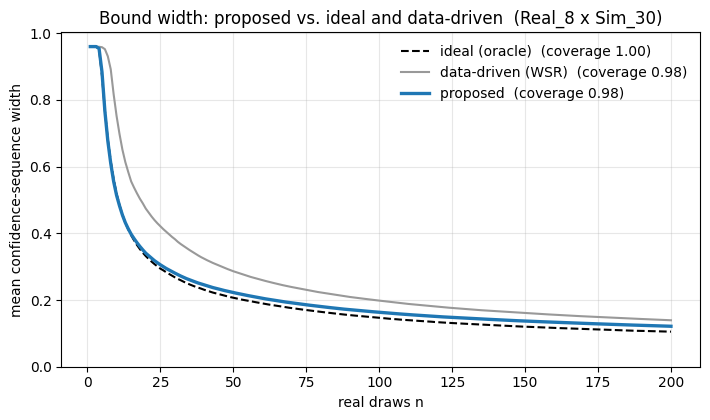

n= 30:  WSR 0.382 -> proposed 0.281 -> ideal 0.268  (89% closed)
n=100:  WSR 0.198 -> proposed 0.163 -> ideal 0.147  (68% closed)
n=200:  WSR 0.139 -> proposed 0.121 -> ideal 0.105  (53% closed)


In [15]:
T, SEEDS = 200, 40
reals, bank = REAL_SETS["Real_8"], BANKS["Sim_30"]()

curves = {
    "ideal (oracle)":    bound_width(reals, "ideal",       T=T, seeds=SEEDS),
    "data-driven (WSR)": bound_width(reals, "data-driven", T=T, seeds=SEEDS),
    "proposed":          bound_width(reals, "proposed", bank=bank, T=T, seeds=SEEDS),
}

n = np.arange(1, T + 1)
style = {
    "ideal (oracle)":    dict(color="k", ls="--"),
    "data-driven (WSR)": dict(color="0.6"),
    "proposed":          dict(color="C0", lw=2.4),
}
plt.figure(figsize=(7.2, 4.3))
for name, (w, cov) in curves.items():
    plt.plot(n, w, label=f"{name}  (coverage {cov:.2f})", **style[name])
plt.xlabel("real draws n")
plt.ylabel("mean confidence-sequence width")
plt.title("Bound width: proposed vs. ideal and data-driven  (Real_8 x Sim_30)")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

wsr, prop, ideal = curves["data-driven (WSR)"][0], curves["proposed"][0], curves["ideal (oracle)"][0]
for nn in (30, 100, 200):
    closed = (wsr[nn-1] - prop[nn-1]) / (wsr[nn-1] - ideal[nn-1])
    print(f"n={nn:3d}:  WSR {wsr[nn-1]:.3f} -> proposed {prop[nn-1]:.3f} -> ideal {ideal[nn-1]:.3f}  ({closed:.0%} closed)")

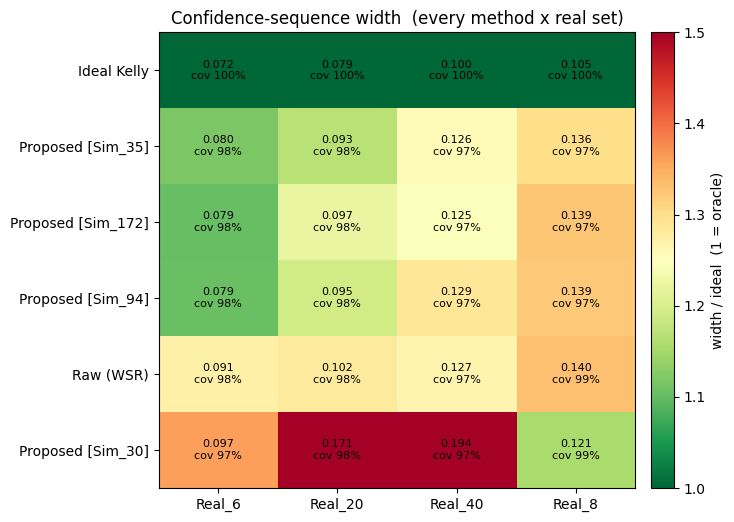

In [16]:
BANK_NAMES = ["Sim_35", "Sim_94", "Sim_172", "Sim_30"]
SET_ORDER  = ["Real_6", "Real_20", "Real_40", "Real_8"]
LABELED = {
    "Real_6":  demo.TEST_DISTRIBUTIONS_Real_6,
    "Real_20": demo.TEST_DISTRIBUTIONS_Real_20,
    "Real_40": demo.TEST_DISTRIBUTIONS_Real_40,
    "Real_8":  [(f"Real_8[{i}]", d) for i, d in enumerate(REAL_SETS["Real_8"])],
}
METHODS = ([("Ideal Kelly", "ideal", None), ("Raw (WSR)", "data-driven", None)]
           + [(f"Proposed [{b}]", "proposed", b) for b in BANK_NAMES])


def cross_product(T=200, seeds=20):
    """Width@T and coverage for every method on every real set (each real summarized once)."""
    union, member = {}, {}
    for sname in SET_ORDER:
        for label, dist in LABELED[sname]:
            union.setdefault(label, dist)
            member.setdefault(label, set()).add(sname)
    experts = {b: BANKS[b]() for b in BANK_NAMES}
    W = {name: {} for name, _, _ in METHODS}
    Cov = {name: {} for name, _, _ in METHODS}
    for label, dist in union.items():
        for name, sizing, b in METHODS:
            w, c = bound_width([dist], sizing, bank=experts[b] if b else None, T=T, seeds=seeds)
            W[name][label], Cov[name][label] = w[-1], c
    fold = lambda D, s: np.mean([D[l] for l in union if s in member[l]])
    names = [name for name, _, _ in METHODS]
    width = np.array([[fold(W[name], s) for s in SET_ORDER] for name in names])
    cover = np.array([[fold(Cov[name], s) for s in SET_ORDER] for name in names])
    return names, width, cover


names, width, cover = cross_product(T=200, seeds=20)

# rank rows best -> worst by average width relative to the oracle, and color by that ratio
ideal = width[names.index("Ideal Kelly")]
order = np.argsort((width / ideal).mean(axis=1))
names = [names[i] for i in order]
width, cover = width[order], cover[order]
ratio = width / width[names.index("Ideal Kelly")]

fig, ax = plt.subplots(figsize=(7.4, 0.62 * len(names) + 1.6))
im = ax.imshow(ratio, cmap="RdYlGn_r", vmin=1.0, vmax=1.5, aspect="auto")
ax.set_xticks(range(len(SET_ORDER)), SET_ORDER)
ax.set_yticks(range(len(names)), names)
for i in range(len(names)):
    for j in range(len(SET_ORDER)):
        ax.text(j, i, f"{width[i, j]:.3f}\ncov {cover[i, j]:.0%}", ha="center", va="center", fontsize=8)
ax.set_title("Confidence-sequence width  (every method x real set)")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03).set_label("width / ideal  (1 = oracle)")
fig.tight_layout()
plt.show()